In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.integrate as integrate

# add path to utils/
from pathlib import Path
import sys

project_root = Path().resolve().parent
sys.path.append(str(project_root))

# import functions from utils/
from utils.importance_sampling import *
from utils.utility import *
from utils.rejection_sampling import *

from scipy.stats import uniform, norm, cauchy

In [ ]:
# log-sum-exp trick
# log_target = ...
# log_proposal = ...
# log_ratio = log_target - log_proposal
# m = np.max(log_ratio)
# ratio = np.exp(log_ratio - m)
# weights = ratio / np.sum(ratio)

# diagnosing numerical instability
# weight_range = np.max(log_ratio) - np.min(log_ratio)
#                < 50     -> safe
#               50-200    -> risky
#               500+      -> extreme instability
#               700+      -> overflow

In [ ]:
# integrating with scipy.integrate
est, abs_err = integrate.quad(
    lambda x: np.exp(-np.sqrt(np.abs(x))), # functions
    a=-100, # limits
    b=100
)
print(est)
# useful for checking normalization constant

3.99800240309038


In [5]:
# q1

est, abs_err = integrate.quad(
    lambda x: x * np.exp(-x**2/2), # functions
    a=5, # limits
    b=50
)
print(est, abs_err)

3.7266531720786747e-06 3.4574348124244666e-11


In [210]:
# Importance Sampling
n_samples = 100_000
x = np.random.normal(loc=5, scale=1, size=n_samples)
acc_samples = x >= 5
x = x[acc_samples]

log_target = -x**2/2
log_proposal = -(x - 5)**2/2
log_ratio = log_target - log_proposal
ratio = np.exp(log_ratio)

weight = ratio / np.sum(ratio)

mu = np.sum(x * weight)
print(mu)

5.18900107358542


In [218]:
# q2
sd = np.sqrt(np.log(25))
x = np.random.normal(0, sd, n_samples)
y = np.random.normal(0, sd, n_samples)

log_target = -x**2/2 - y**2/2
log_proposal = -x**2/(2*sd**2) - y**2/(2*sd**2) - 2 * np.log(sd)
log_ratio = log_target - log_proposal
ratio = np.exp(log_ratio)

ind = np.exp(x) + np.exp(y) > 50

est = 1e4 * np.mean(ind * ratio)
print(est)


1.0916763107582927


In [10]:
# q3

x = np.random.uniform(0, 5, n_samples)
y = np.random.uniform(0, 5, n_samples)

log_target = 3 * np.log(x + y)
log_proposal = np.log(0.04)
log_ratio = log_target - log_proposal
m = np.max(log_ratio)
ratio = np.exp(log_ratio - m)

weight = ratio / np.sum(ratio)

mu_y = np.sum(y * weight)
mu_y2 = np.sum(y**2 * weight)
std_est = np.sqrt(mu_y2 - mu_y**2)
print(std_est)

1.2125736438887922


In [14]:
ess = 1 / np.sum(weight**2)
print(ess)

49598.01523949421


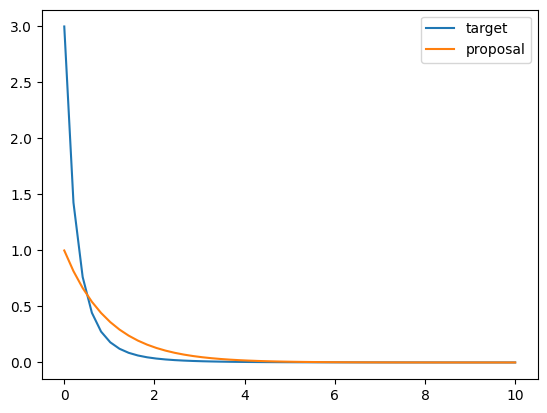

In [44]:
# q4
pdf = lambda x: 3 * (1 + x)**(-4)

n_samples = 100_000

x = np.linspace(0, 10)
y = pdf(x)
z = np.exp(-x)
plt.plot(x, y, label="target")
plt.plot(x, z, label="proposal")
plt.legend()
plt.show()

In [65]:
n_samples = 1_000_000
x = np.random.standard_exponential(n_samples)

log_target = -4 * np.log(1 + x) + np.log(3)
log_proposal = -x
log_ratio = log_target - log_proposal
m = np.max(log_ratio)
ratio = np.exp(log_ratio - m)

weight = ratio / np.sum(ratio)
ess = 1 / np.sum(weight**2)
print(ess)

mu_x = np.sum(x * weight)
mu_x2 = np.sum(x**2 * weight)

std_est = np.sqrt(mu_x2 - mu_x**2)
print(std_est)
# 0.774

628728.6523811152
0.7749006251049322


In [71]:
# q5
K = 6
sd = np.sqrt(3)
X = np.random.normal(0, sd, (n_samples, K))
S = np.sum(X**2, axis=1)

log_ratio = -S/2 + S/(2*sd**2) + K * np.log(sd) # be careful of the density
ratio = np.exp(log_ratio)

ind = S > 22
est = 1e3 * np.mean(ind * ratio) 
print(est)
# 1.21

1.2113985007169694


In [72]:
# q6
n_samples = 100_000
roll_count = np.empty(n_samples)
for i in range(n_samples):
    count = 0
    consec = 0
    while True:
        toss = np.random.choice([1, 2, 3, 4, 5, 6])
        count += 1
        if toss == 6:
            consec += 1
        else:
            consec = 0

        if consec == 2:
            roll_count[i] = count
            break
    
np.mean(roll_count)
# 

np.float64(42.00717)

In [73]:
generate_mean_and_std_err(roll_count)

Mean: 42.0072
Standard Error: 0.1291


In [74]:
# q7

x = np.random.standard_exponential(n_samples)
g = np.cos(2 * x)
int_est = 2 * np.mean(g)
print(int_est)

0.404380970185864


In [75]:
est, abs_err = integrate.quad(
    lambda x: np.exp(-np.abs(x)) * np.cos(2 * x), # functions
    a=-100, # limits
    b=100
)
print(est, abs_err)

0.40000000000000036 4.202607640195633e-09


In [82]:
# q8
T = 10
mu = 3
z = np.random.normal(loc=mu, scale=1, size=(n_samples, 10))
s = np.cumsum(z, axis=1)

# IS 
log_target = np.sum(-z**2/2, axis=1)
log_proposal = np.sum(-(z - mu)**2/2, axis=1)
log_ratio = log_target - log_proposal
ratio = np.exp(log_ratio)

i = np.all(s > 3, axis=1)

prob = np.mean(i * ratio)
print(1e4 * prob)
# 1.50

1.3601375826106585e-05


In [93]:
# q9
x = np.random.uniform(0, 1, n_samples)
y = np.random.uniform(0, 1, n_samples)

ind = np.abs(x - y) > 1 - 1e-2
prob = np.mean(ind)
print(1e4 * prob)

0.9


In [97]:
exact = 1e-2 * 1e-2 / 2 + 1e-2 * 1e-2 / 2
print(exact * 1e4)

1.0


In [100]:
# q10
def generate_one_sample():
    K = 8
    mu=22/8
    rate = 1/mu
    x = np.random.exponential(scale=mu, size=(K,))
    s = np.sum(x)

    log_ratio = np.sum(-x - np.log(rate) + rate*x)
    ratio = np.exp(log_ratio)
    i = (s > 22).astype(float)

    return i * ratio

samples = [generate_one_sample() for _ in range(100_000)]
np.mean(samples) * 1e3
# 0.1981

np.float64(0.19822698424112453)

In [115]:
# q11
est, abs_err = integrate.quad(
    lambda x: np.sin(x)**2 / (1 + 2 * x**2), # functions
    a=-100, # limits
    b=100
)
print(est, abs_err)

0.8357079698372041 5.372111755152037e-10


In [121]:
n_samples = 1_000_000
x = np.random.standard_cauchy(n_samples)
factor = 1 / np.sqrt(2)
samples = np.pi * factor * np.sin(factor * x)**2
generate_mean_and_std_err(samples)

Mean: 0.8406
Standard Error: 0.0008


In [151]:
# q12
n_samples = 10_000_000
sigma_q = 0.5
x = np.random.normal(0, sigma_q, n_samples)
y = np.random.normal(0, sigma_q, n_samples)

ind = x**2 + y**2 < 0.01

log_target = -(x**2 + y**2)/2
log_proposal = -(x**2 + y**2)/(2 * sigma_q**2) - 2 * np.log(sigma_q)
log_ratio = log_target - log_proposal
ratio = np.exp(log_ratio)

est = 1e4 * np.mean(ind * ratio)
print(est)

49.80003066134245


In [152]:
# q13
f = lambda x: np.sqrt(x) * np.exp(-3 * x)
est, abs_err = integrate.quad(
    f, # functions
    a=0, # limits
    b=100
)
print(est, abs_err)

0.1705544513243818 2.653636033134177e-09


In [160]:
lam = 3
x = np.random.exponential(scale=1/lam, size=n_samples)
samples = 1/3 * np.sqrt(x)
generate_mean_and_std_err(samples)
print(np.mean(x))

Mean: 0.1706
Standard Error: 0.0000
0.3334835831240087


In [162]:
# q14
K = 8
u = np.random.uniform(0, 1, (n_samples, K))
u_min = np.min(u, axis=1)
u_max = np.max(u, axis=1)

samples = u_max - u_min
generate_mean_and_std_err(samples)

Mean: 0.7777
Standard Error: 0.0000


In [191]:
# q15
x = np.random.standard_cauchy(n_samples)

log_target = -np.log(1 + x**4)
log_proposal = -np.log(1 + x**2) - np.log(np.pi)
log_ratio = log_target - log_proposal
ratio = np.exp(log_ratio)

weight = ratio / np.sum(ratio)

mu2 = np.sum(x**2 * weight)
print(mu2)

1.0015206181904037


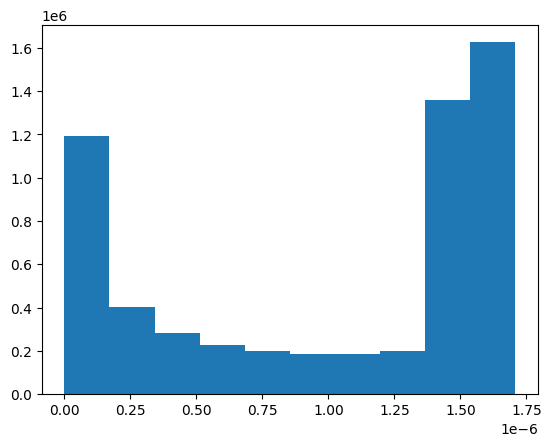

In [192]:
plt.hist(weight, density=True)
plt.show()

In [ ]:
# q16

np

In [177]:
# q17
n_samples = 1_000_000
K = 30
flips = np.random.choice([0, 1], size=(n_samples, K), p=[0.3, 0.7])
heads = np.sum(flips, axis=1)

tails = 30 - heads
log_ratios = 30 * np.log(0.5) - heads * np.log(0.7) - tails * np.log(0.3)
ratios = np.exp(log_ratios)

ind = heads >= 24
print(1e3 * np.mean(ind * ratios))

0.7137870878082935


In [178]:
from scipy.stats import binom

p = 1 - binom.cdf(23, n=30, p=0.5)
1e3 * p

np.float64(0.715453177690506)

In [175]:
1 - binom.cdf(1, n=2, p=0.5)

np.float64(0.25)

In [181]:
# q18
f = lambda x: 1/ (1 + x**4)
est, abs_err = integrate.quad(
    f, # functions
    a=-100, # limits
    b=100
)
print(est, abs_err)

2.2214408024125194 2.6325111456503535e-14


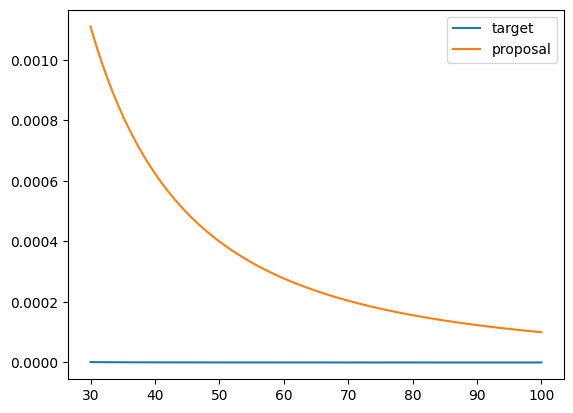

In [188]:
xx = np.linspace(30, 100, 1000)
yy = f(xx)
zz = 1 / (1 + xx**2)
plt.plot(xx, yy, label="target")
plt.plot(xx, zz, label="proposal")
plt.legend()
plt.show() # good to go

In [189]:
x = np.random.standard_cauchy(n_samples)
samples = np.pi * (1 + x**2) / (1 + x**4)

generate_mean_and_std_err(samples)

Mean: 2.2216
Standard Error: 0.0014


In [196]:
# q19

n_samples = 1_000_000
x = np.random.uniform(0, 5, n_samples)

# SNIS with uniform proposal
log_target = 3 * np.log(x) + 2 * np.log(5 - x)
log_proposal = np.log(0.2)
log_ratio = log_target - log_proposal
ratio = np.exp(log_ratio)

weight = ratio / np.sum(ratio)

mu2 = np.sum(x**2 * weight)

print(mu2)

8.930981303885874


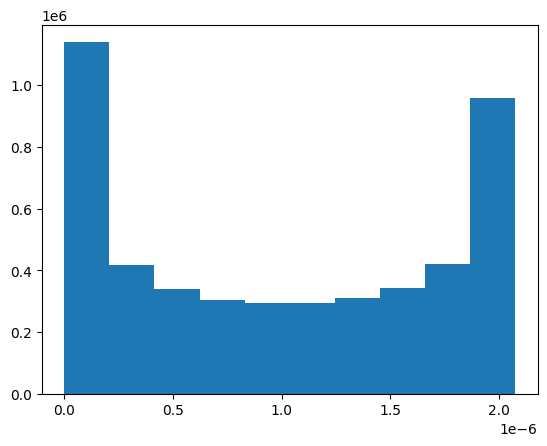

In [195]:
plt.hist(weight, density=True)
plt.show()

In [199]:
# q20
n_samples = 1_000_000
x = np.random.uniform(0, 1, n_samples)

log_target = x
log_proposal = np.log(1)
log_ratio = log_target - log_proposal
ratio = np.exp(log_ratio)

weight = ratio / np.sum(ratio)

mu = np.sum(x * weight)
mu2 = np.sum(x**2 * weight)
std_est = np.sqrt(mu2 - mu**2)
print(std_est)

0.281739511098056
